## Mejias et al 2022 model
- the only matrix operation that we use is for computing the synaptic input to a region from all other regions
- this will allow for using matrices to run several trials in parallel (not implemented here)

In [1]:
import numpy as np
from numpy import matlib
import matplotlib.pyplot as plt
import pandas
import scipy.io as sio

### Transfer functions

Define the function that transforms input current to changes in firing rate for excitatory neurons (Abbott and Chance, 2005). 
<br>
$$r_E = \frac{aI_{syn,E} - b}{1 - e^{-d(aI_{syn,E} - b)}} $$

Update the firing rates of the interneurons using a threshold linear input/output function
$$ \begin{cases}
  r_I = \frac{1}{g_2}(c_II_{syn,I} - c_0) + r_0 & \text{for } r_I\ge 0\\    
  r_I = 0     & \text{otherwise }  
\end{cases} $$


In [2]:

def phi_E(I, a_E, b_E, d_E):    
    return (a_E * I - b_E) / (1 - np.exp(-d_E * (a_E * I - b_E)))
    
def phi_I(I, g_I, c_1, c_0, r0_I):    
    return np.maximum( (1/g_I) * (c_1 * I - c_0) + r0_I, 0)


### Load the anatomical data

In [3]:

subgraph_data = sio.loadmat('../data/subgraphData30.mat')

fln = subgraph_data['fln']  # FLN (fraction of labelled neurons)
sln = subgraph_data['sln']  # 
hierarchy = np.squeeze(subgraph_data['hierVals'])

area_list = ['V1','V2','V4','DP','MT','8m','5','8l','2','TEO','F1','STPc','7A','46d','10','9/46v','9/46d','F5','TEpd','PBr','7m','LIP','F2','7B','ProM','STPi','F7','8b','STPr','24c']
frontal = np.array([5,7,10,13,14,15,16,17,22,24,26,27]);  # areas in frontal lobe

num_areas = fln.shape[0]


# SPINE COUNT DATA (Elston, several papers):
spinec = np.array([643, 1201, 2429, -10, 2077, 3200, 4689, 3200, -10, 4812, -10, 8337, 2572, 6600,  # 46d
    6488, 7800, 7800, -10, 6200, -10, 2294, 2316, -10, 6841, -10, 8337, -10, -10, 8337, 6825])  #24c
# age factor:
AF = np.ones((num_areas,))
AF[[13,14,15,16,18,29]] = AF[[13,14,15,16,18,29]] * 1.15  # 5yo, 15% increase
AF[[5,7,20]] = AF[[5,7,20]] * 1.30  # 10yo, 30% increase
spinec = spinec * AF  # age correction
hierVals2 = spinec / np.max(spinec)

# now the ones based on hierarchical positions:
hierVals2[spinec < 0] = hierarchy[spinec < 0]


### Parameters

In [4]:
with_Mejias_version = True  # True: Use local gradients as defined in Mejias et al 2022; False: use hierarchy as in Python version from XJ Wang's lab homepage
with_debug = True

# Set up simulation parameters
dt = 0.5 * 1e-3  # timestep [s]
dt_rate = 10e-3  # store firing rate every 10 ms
trial_length = 10  # trial length (s)
num_iterations = int(trial_length/dt)
num_pops = 3

# Stimulus and distractor
stim_on = 4.0  # s
stim_off = 4.5  # s
distract_on = 3.5  # s
distract_off = 4.0  # s
stim_strength = 0.3  # nA
distractor_strength = 0  # nA

# Time constants
tau_NMDA = 60 * 1e-3  # s
tau_GABA = 5 * 1e-3  # s
tau_AMPA = 2 * 1e-3  # s
tau_r = 2 * 1e-3  # s

# Kinetic parameters of NMDA and GABA
gamma = 1.282  # unitless
gamma_i = 2.  # unitless

# f-I curve parameters - E populations
a_E = 135.  # Hz/nA
b_E = 54.  # Hz
d_E = 0.308  # s

# f-I curve parameters - I populations
g_I = 4.  # unitlessK
c_1 = 615.  # Hz/nA
c_0 = 177.  # Hz
r0_I = 5.5  # Hz

# Local connectivity matrix strengths
# Strength of connections from E cells
g_E_self_local = 0.3213  # nA   parameter for local network without long-range connectivity and synaptic strength gradient
g_E_self = 0.21
g_E_self_min = 0.21  # nA
g_E_self_max = 0.42  # nA
g_E_cross = 0.0107  # nA
g_I_E_local = 0.15  # nA   parameter for local network without long-range connectivity and synaptic strength gradient

# Strength of connections from I cells
g_E_I = -0.31  # nA
g_I_I = -0.12  # nA

# excitatory input constant ("John Murray's term")
J_0 = 0.2112  # nA - Matches value in John Murray's thesis for g_E_self - g_E_cross
## J_0 can be computed (using zeta defined below) as:
#J_0_ = g_E_self_local + g_E_cross + 2 * g_E_I * g_I_E_local * zeta
#print('J0 = ',J_0_, ' (', J_0, ')')

# global coupling strength
G = 0.48  # unitless

# Background inputs
I0_E = 0.3294  # nA
I0_I = 0.26  # nA

# Noise std dev
std_noise = 0.01  # nA


### Set up the simulation

In [5]:
######## HIERARCHY ########

if with_Mejias_version:
    # Gradient with real spine count and hierarchical values
    g_E_self = g_E_self_min + (g_E_self_max - g_E_self_min) * hierVals2
else:
    ## Scale the local E to E synapses to lie according to the hierarchy
    g_E_self = g_E_self_min + (g_E_self_max - g_E_self_min) * hierarchy

# Scale the E to I synapses to lie along the hierarachy (ensuring that the spontaneous activity fixed point is the same across areas)
zeta = c_1 * tau_GABA * gamma_i / (g_I - g_I_I * tau_GABA * gamma_i * c_1)  # Eq. 14
g_I_E = (J_0 - g_E_self - g_E_cross) / (2 * zeta * g_E_I)    # Eq. 17


####### LONG-RANGE CONNECTIONS ########

# Long-range coupling strength
mu_EE = G  
Z = 2 * c_1 * tau_GABA * gamma_i * g_E_I / (c_1 * tau_GABA * gamma_i * g_I_I - g_I)    # constant to maintain EI balance; Eq. 21
mu_IE = G / Z

# Compress FLN (fraction of labelled neurons)
fln_squish = 1.2 * np.power(fln,0.3)
fln_rowtotal = np.sum(fln_squish,axis=1)
fln_squishnorm = fln_squish / fln_rowtotal[:, np.newaxis]

# Make feedforward connections target more excitatory cells
W_E = fln_squishnorm * sln

# Make feedback connections target more inhibitory cells
lambdai = np.ones((num_areas,num_areas)) - sln
if with_Mejias_version:
    # We cap the inhibitory long-range strength to FEF from frontal areas.
    maxi = 0.4
    idx = lambdai[frontal[0],frontal] > maxi
    lambdai[frontal[0],frontal[idx]] = maxi
    idx = lambdai[frontal[1],frontal] > maxi
    lambdai[frontal[1],frontal[idx]] = maxi
W_I = fln_squishnorm * lambdai
                  

####### CONNECTIVITY MATRIX ########

# compute effective connectivity matrix for excitatory connections
LR_EE_gradient = g_E_self / np.max(g_E_self)
W_E_eff = mu_EE * LR_EE_gradient[:, np.newaxis] * W_E 
np.fill_diagonal(W_E_eff, g_E_self)  # include self population weights in effective connectivity matrix

# compute effective connectivity matrix for inhibitory connections
LR_IE_gradient = g_I_E / np.max(g_I_E)
W_I_eff = mu_IE * LR_IE_gradient[:, np.newaxis] * W_I 
np.fill_diagonal(W_I_eff, g_I_E)

# construct joint connectivity matrix for all 3 populations (E1, E2, and I)
W_eff = np.zeros((num_areas*num_pops,num_areas*num_pops))
W_eff[:num_areas,:num_areas] = W_E_eff  # excitatory to excitatory connections E1 -> E1
W_eff[num_areas:2*num_areas,num_areas:2*num_areas] = W_E_eff  # excitatory to excitatory connections E2 -> E2
np.fill_diagonal(W_eff[:num_areas,num_areas:2*num_areas], g_E_cross)  # excitatory to excitatory connections E1 -> E2
np.fill_diagonal(W_eff[num_areas:2*num_areas,:num_areas], g_E_cross)  # excitatory to excitatory connections E2 -> E1
W_eff[2*num_areas:,:num_areas] = W_I_eff  # excitatory to inhibitory connections E1 -> I
W_eff[2*num_areas:,num_areas:2*num_areas] = W_I_eff  # excitatory to inhibitory connections E2 -> I
np.fill_diagonal(W_eff[:num_areas,2*num_areas:], g_E_I)  # inhibitory to excitatory connections I -> E1
np.fill_diagonal(W_eff[num_areas:2*num_areas,2*num_areas:], g_E_I)  # inhibitory to excitatory connections I -> E2
np.fill_diagonal(W_eff[2*num_areas:,2*num_areas:], g_I_I)  # inhibitory to inhibitory connections I -> I


####### EXT INPUTS AND NOISE ########

# background inputs
I0 = np.concatenate((I0_E * np.ones(2*num_areas,), I0_I * np.ones(num_areas,) ))

# Let's apply external stimulation to V1 populations E1 & E2
I_ext = np.zeros((num_iterations,num_areas * num_pops))
I_ext[int(stim_on/dt):int(stim_off/dt),area_list.index('V1')] = stim_strength
I_ext[int(distract_on/dt):int(distract_off/dt),area_list.index('V1')+num_areas] = distractor_strength

# Let's set up the noise. We will model the noise as an Ornstein-Uhlenbeck process.
# Gaussian noise. mean 0, std 1. Dims: timesteps, local populations, areas
eta = np.random.normal(loc=0.0, scale=1.0, size=(num_iterations,num_areas * num_pops))
noise_rhs = eta * np.sqrt(dt/tau_AMPA) * std_noise
noise_rhs[:,2*num_areas:] = 0.0  # no noise for inhibitory neurons


### Plot connectivity matrix

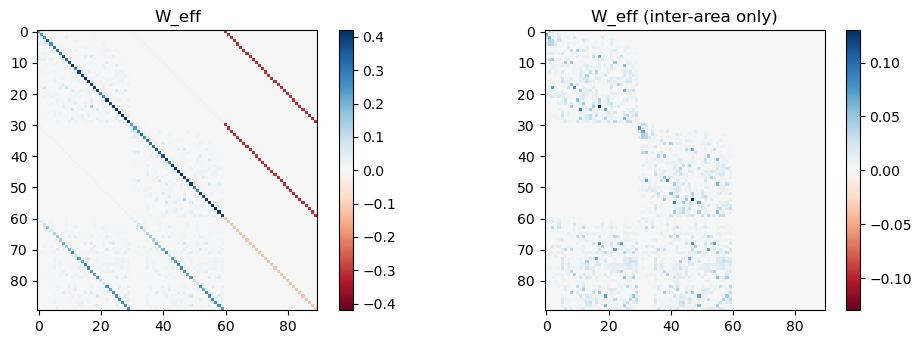

In [6]:
# connectivity matrix for excitatory and inhibitory neurons
plt.figure(figsize=(12,8))
           
plt.subplot(2,2,1)
plt.imshow(W_eff,cmap='RdBu',vmin=-np.max(W_eff),vmax=np.max(W_eff))
plt.colorbar()
plt.title('W_eff');

plt.subplot(2,2,2)
W_eff_ = W_eff.copy()
np.fill_diagonal(W_eff_, 0)
np.fill_diagonal(W_eff_[:2*num_areas,num_areas:], 0)
np.fill_diagonal(W_eff_[num_areas:,:2*num_areas], 0)
np.fill_diagonal(W_eff_[:num_areas,2*num_areas:], 0)
np.fill_diagonal(W_eff_[2*num_areas:,:num_areas], 0)
plt.imshow(W_eff_,cmap='RdBu',vmin=-np.max(W_eff_),vmax=np.max(W_eff_))
plt.colorbar()
plt.title('W_eff (inter-area only)');


### Run the simulation

In [7]:

import timeit
start = timeit.default_timer()

# Preassign rate and synapse matrices
r = np.zeros((num_areas * num_pops,))
r_E = r[:2*num_areas]  # note that these slices of r are not copies but pointers to r
r_I = r[2*num_areas:]
S = np.zeros((num_areas * num_pops,))
S_NMDA = S[:2*num_areas]  # note that these slices of S are not copies but pointers to S
#S_NMDA_E1 = S[:num_areas]
#S_NMDA_E2 = S[num_areas:2*num_areas]
S_GABA = S[2*num_areas:]

# Noise
I_noise = np.zeros((num_areas*num_pops,))

# Firing rate
saving_counter = 1
saving_factor = int(dt_rate // dt)
R = np.zeros((int(num_iterations // saving_factor), num_areas * num_pops))

# Create matrices in which we can store the currents
I_total = np.zeros((num_areas * num_pops,))
I_total_E = I_total[:2*num_areas]  # note that these slices of I_total are not copies but pointers to I_total
#I_total_E1 = I_total[:num_areas]
#I_total_E2 = I_total[num_areas:2*num_areas]
I_total_I = I_total[2*num_areas:]
#I_NMDA_E1 = np.zeros((num_areas,))
#I_NMDA_E2 = np.zeros((num_areas,))
#I_NMDA_I = np.zeros((num_areas,))
#I_GABA_E = np.zeros((num_areas,))
#I_GABA_I = np.zeros((num_areas,))

for i_t in range(1,num_iterations):
    
    # update noise - dims = num local pops x num areas
    I_noise = I_noise - (dt/tau_AMPA) * I_noise + noise_rhs[i_t-1,:]
    I_noise = 0.0 * I_noise

    # compute all the synaptic input using the joint connectivity matrix W_eff
    # this is equivalant to the code that is commented out (see below)
    I_total[:] = W_eff @ S + I0 + I_ext[i_t-1,:] + I_noise
    
    # Update the firing rates of the two excitatory and the inhibitory populations
    r_E[:] = r_E + dt/tau_r * (-r_E + phi_E(I_total_E, a_E, b_E, d_E) )
    r_I[:] = r_I + dt/tau_r * (-r_I + phi_I(I_total_I, g_I, c_1, c_0, r0_I) )
    
    # Update the NMDA synapses
    S_NMDA[:] = S_NMDA + dt * (-S_NMDA / tau_NMDA + gamma * (1 - S_NMDA) * r_E)
    
    # Update the GABA synapses
    S_GABA[:] = S_GABA + dt * (-S_GABA / tau_GABA + gamma_i * r_I)
    
    # Store firing rates of all populations
    if i_t % saving_factor == 0:
        R[saving_counter,:] = r
        saving_counter += 1
    
    ## Here is a more step-by-step calculation of the synaptic inputs which is identical to the simple
    ## "I_total[:] = W_eff @ S + I0 + I_ext[i_t-1,:] + I_noise" above
    ##
    ## Long range input to E-pops is a sum of NMDA only (see large_scale_monkey_interneurons for version with AMPA)
    ## weighted by long-range connectivity strength(FLN), Cross & Self population weights
    #I_NMDA_E1 = W_E_eff @ S_NMDA_E1 + g_E_cross * S_NMDA_E2
    #I_NMDA_E2 = W_E_eff @ S_NMDA_E2 + g_E_cross * S_NMDA_E1
    #I_NMDA_I = W_I_eff @ (S_NMDA_E1 + S_NMDA_E2)
    #
    ## sum up all the local GABA current onto E and I cells
    #I_GABA_E = g_E_I * S_GABA
    #I_GABA_I = g_I_I * S_GABA
    # 
    ## Define total input current as sum of local NMDA & GABA inputs, with background and external currents, 
    ## noise and long-range NMDA inputs
    #I_total_E1 = I_NMDA_E1 + I_GABA_E + I0_E + I_ext[i_t-1,:num_areas] + I_noise[:num_areas]
    #I_total_E2 = I_NMDA_E2 + I_GABA_E + I0_E + I_ext[i_t-1,num_areas:2*num_areas] + I_noise[num_areas:2*num_areas]
    #I_total_I = I_NMDA_I + I_GABA_I + I0_I + I_ext[i_t-1,2*num_areas:] + I_noise[2*num_areas:]

    
print('execution time: ', timeit.default_timer() - start)


execution time:  0.4389083749993006


### Plot neural activity of all brain areas

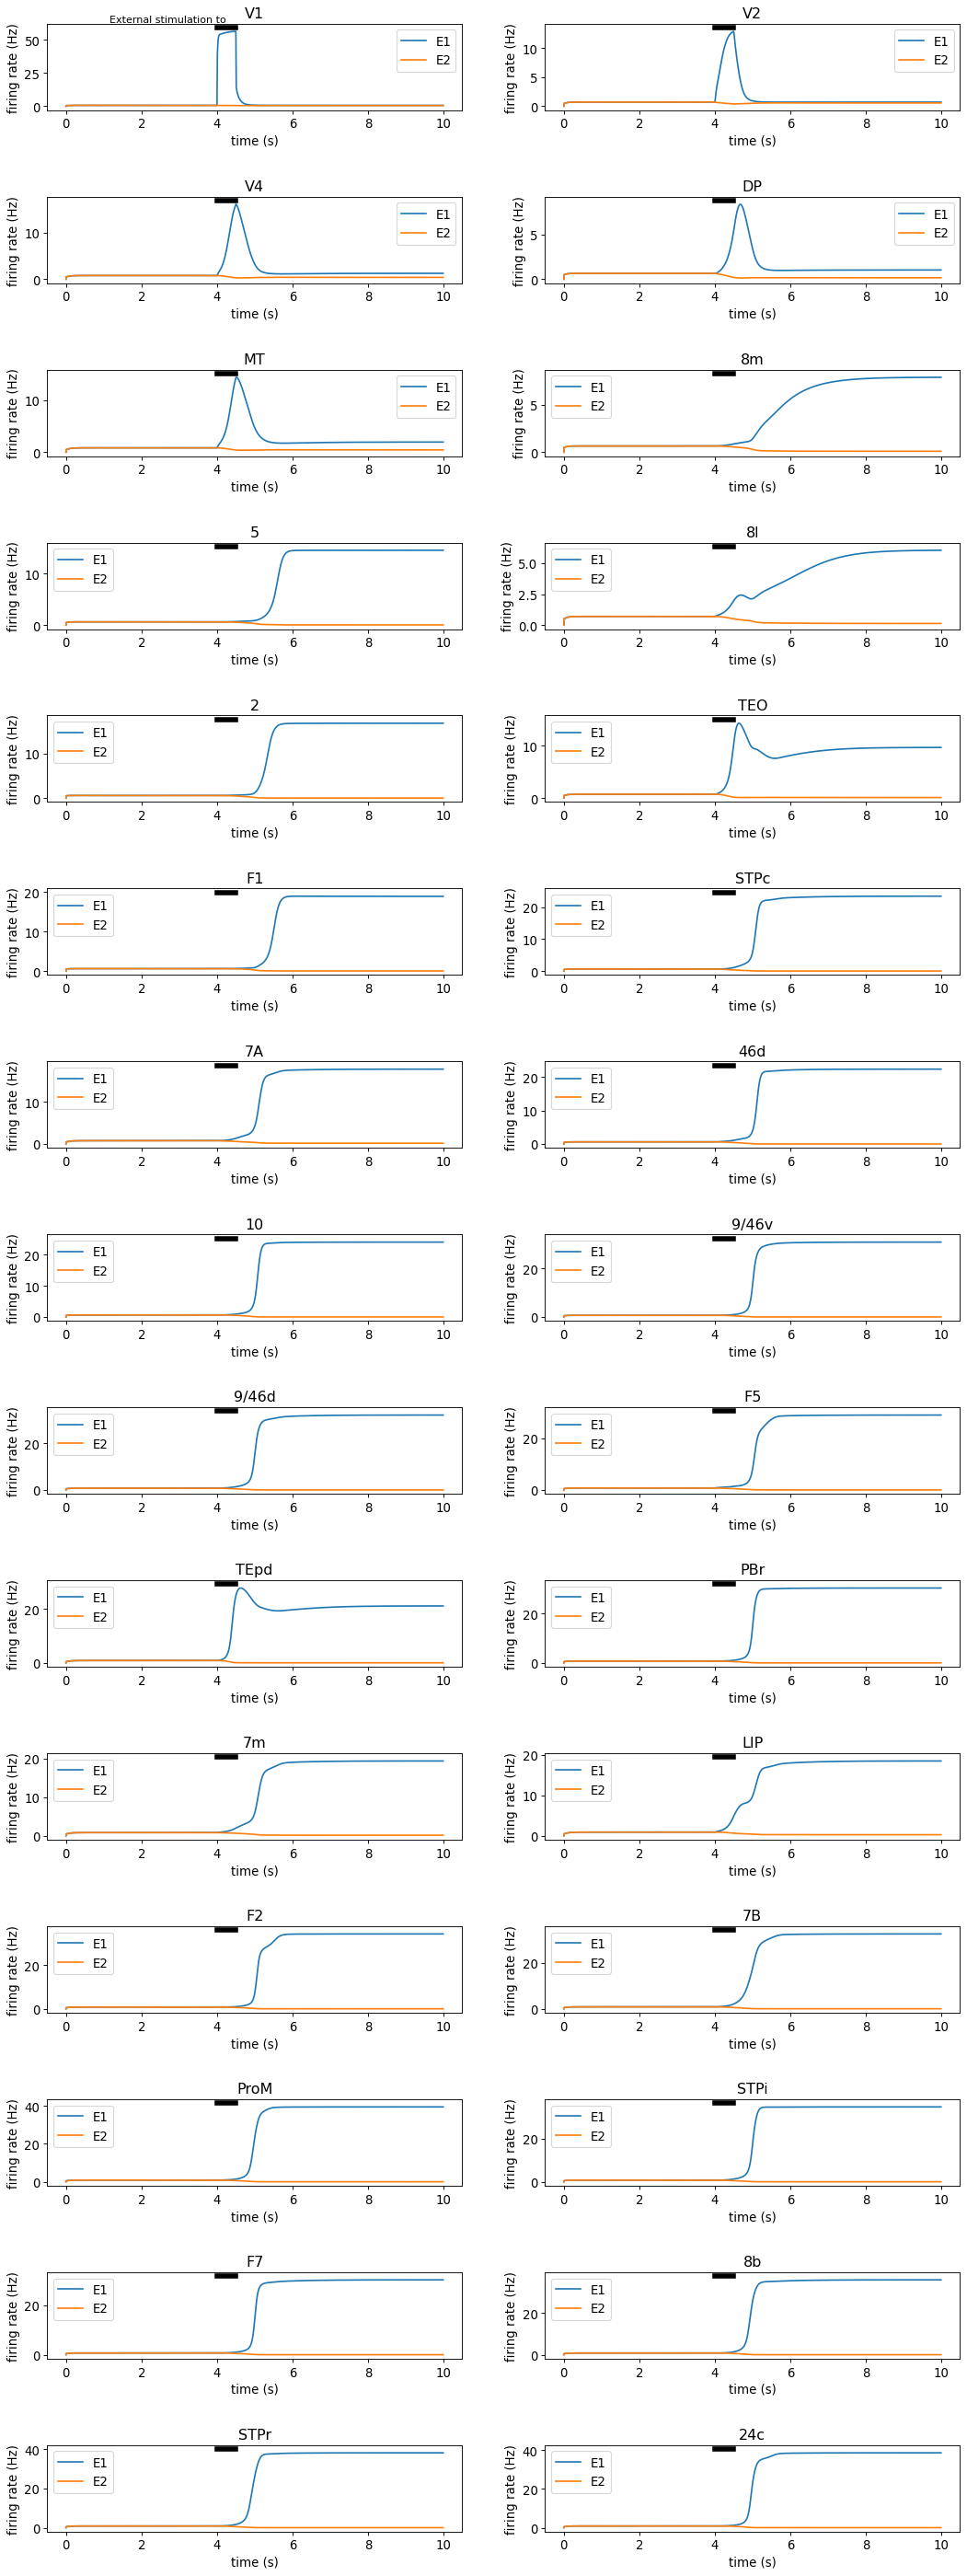

In [8]:
R_E1 = R[:,:num_areas]
R_E2 = R[:,num_areas:2*num_areas]
R_I = R[:,2*num_areas:]
t = np.arange(0, trial_length, dt_rate)

fig = plt.figure(figsize=(16,90), dpi= 80, facecolor='w', edgecolor='k')
plt.rcParams.update({'font.size': 12})

for i in range(1,num_areas+1):
    ax = plt.subplot(num_areas,2,i)
    ax.set_title(area_list[i-1])
    # Plot the rates for the E1 soma
    plt.subplots_adjust(hspace = 1)
    plt.plot(t, R_E1[:,i-1])
    plt.plot(t, R_E2[:,i-1])
    
    # Plot the stimulation time
    plt.plot([stim_on,stim_off],[np.max(R_E1[:,i-1]+0.05*np.max(R_E1[:,i-1])),np.max(R_E1[:,i-1]+0.05*np.max(R_E1[:,i-1]))],color='black',linewidth=5.0)
    
    # place text above the black line
    axes = plt.gca()
    if i==1:
        axes.text(0.15, 1.1,'External stimulation to', transform=axes.transAxes, fontsize=10, verticalalignment='top')

    plt.legend(['E1','E2'])
    plt.xlabel('time (s)')
    plt.ylabel('firing rate (Hz)')
#    plt.ylim(0, 60) 

### Plot firing rates as a function of hierarchy ("bifurcation in space")

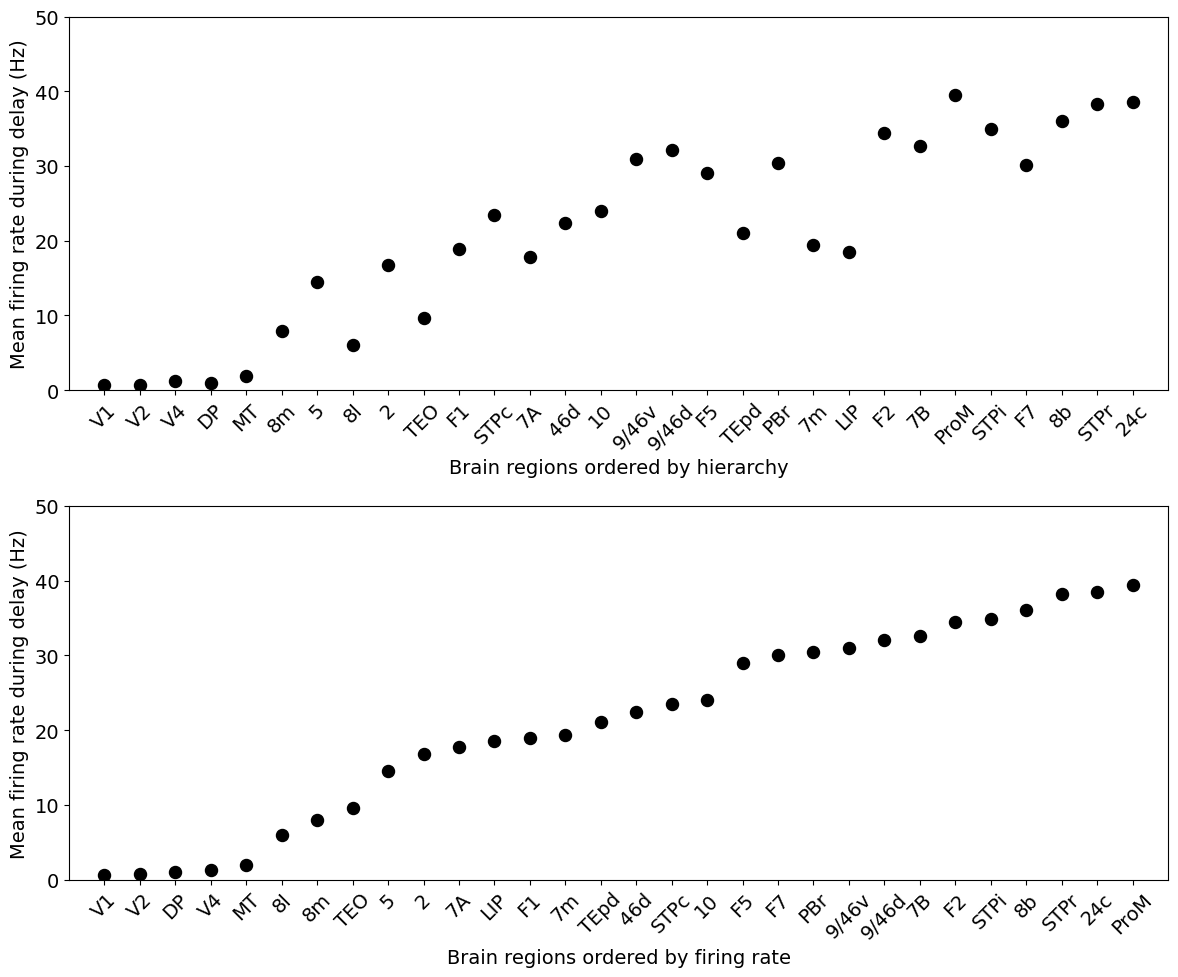

In [9]:
# plot the mean delay activity of all areas ordered by hierarchy

delay_rate = np.mean(R_E1[-100:,:],axis=0)
sort_idx = np.argsort(delay_rate)
sorted_areas = [area_list[i] for i in sort_idx]

plt.rc('font', size = 14)
fig, (ax1, ax2) = plt.subplots(2,1,figsize=[12, 10])

ax1.scatter(x=np.arange(1,num_areas+1), y=delay_rate, color='k', s=75)
ax1.set_xlabel('Brain regions ordered by hierarchy')
ax1.set_xlim([0, num_areas+1])
ax1.set_xticks(range(1,num_areas+1))
ax1.set_xticklabels(area_list, rotation=45)
ax1.set_ylim([0, 50])
ax1.set_ylabel('Mean firing rate during delay (Hz)')

ax2.scatter(x=np.arange(1,num_areas+1), y=delay_rate[sort_idx], color='k', s=75)
ax2.set_xlabel('Brain regions ordered by firing rate')
ax2.set_xlim([0, num_areas+1])
ax2.set_xticks(range(1,num_areas+1))
ax2.set_xticklabels(sorted_areas, rotation=45)
ax2.set_ylim([0, 50])
ax2.set_ylabel('Mean firing rate during delay (Hz)')

fig.tight_layout()
fig.savefig('delay_activity_all_areas.png')

In [10]:
if with_debug:

    # compare to original version (results should be the same if the noise is set to zero)
    import scipy
    #results = scipy.io.loadmat('test.mat')
    #print(sum(abs(results['R'][-1,:,0] - R_E1[-1,:])))

    # save results for comparison with Jorge Mejias' Matlab implementation
    scipy.io.savemat('test2.mat',{'g_E_self':g_E_self,'g_I_E':g_I_E,'W_E_eff':W_E_eff,'W_I_eff':W_I_eff,'delay_rate':delay_rate,'R':R})
    